# Lab 08: Statistics & Random Sampling

## Examples (by instructor)

In this lab, you'll apply the statistics tools from Chapter 13 to real engineering data: summarizing datasets with descriptive statistics, working with probability distributions (uniform and normal), computing probabilities using the CDF and PPF, and building confidence intervals for the mean.

### Example 1: Descriptive Statistics

Given 10 batch yields (%): `82.1, 85.4, 79.8, 83.7, 86.2, 81.0, 84.5, 80.3, 85.9, 82.8`

Compute mean, median, sample std, and the fraction below 81%.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

yields = np.array([82.1, 85.4, 79.8, 83.7, 86.2, 81.0, 84.5, 80.3, 85.9, 82.8])

print(f"Mean   : {np.mean(yields):.2f} %")
print(f"Median : {np.median(yields):.2f} %")
print(f"Std    : {np.std(yields, ddof=1):.2f} %  (sample, ddof=1)")
print(f"Below 81% : {np.sum(yields < 81)} / {len(yields)} batches")

Mean   : 83.17 %
Median : 83.25 %
Std    : 2.34 %  (sample, ddof=1)
Below 81% : 2 / 10 batches


### Example 2: Normal Distribution — CDF and PPF

Reactor temperature follows $\mathcal{N}(\mu=350\text{ K},\; \sigma=5\text{ K})$.

1. What fraction of the time is temperature below 343 K?
2. What temperature is exceeded only 5% of the time?

In [5]:
dist_T = stats.norm(loc=350, scale=5)

# 1. P(T < 343)
print(f"P(T < 343 K) = {dist_T.cdf(343):.4f}")

# 2. Temperature exceeded only 5% of the time → 95th percentile
print(f"T exceeded 5% of the time = {dist_T.ppf(0.95):.2f} K")

P(T < 343 K) = 0.0808
T exceeded 5% of the time = 358.22 K


### Example 3: Confidence Interval for the Mean

Five repeat measurements of outlet concentration (mol/L): `2.31, 2.28, 2.35, 2.29, 2.33`

Compute the 95% confidence interval using the $t$-distribution.

In [6]:
C = np.array([2.31, 2.28, 2.35, 2.29, 2.33])

n  = len(C)
xbar = np.mean(C)
se   = np.std(C, ddof=1) / np.sqrt(n)

lo, hi = stats.t.interval(0.95, df=n-1, loc=xbar, scale=se)
print(f"Mean = {xbar:.4f} mol/L")
print(f"95% CI: [{lo:.4f}, {hi:.4f}] mol/L  (width = {hi-lo:.4f})")

Mean = 2.3120 mol/L
95% CI: [2.2764, 2.3476] mol/L  (width = 0.0711)


---

## Warm-Up: Syntax Practice

Short exercises to get comfortable with the key statistics functions before the main problems.

**Exercise 1 — Descriptive statistics.**

Given the following 8 reactor conversion measurements (%), compute the mean, median, sample standard deviation, and IQR. Then print whether the mean and median are close (within 1%).

```
78.2, 81.5, 76.9, 83.1, 79.4, 80.7, 77.8, 82.3
```

In [ ]:
import numpy as np

X = np.array([78.2, 81.5, 76.9, 83.1, 79.4, 80.7, 77.8, 82.3])

mean   = ___                          # mean
median = ___                          # median
std    = ___                          # sample std dev (ddof=1)
iqr    = ___ - ___                    # Q3 - Q1 (use np.percentile)

print(f"Mean   = {mean:.2f} %")
print(f"Median = {median:.2f} %")
print(f"Std    = {std:.2f} %")
print(f"IQR    = {iqr:.2f} %")

if abs(mean - median) < 1.0:
    print("Mean and median are close — distribution is roughly symmetric.")
else:
    print("Mean and median differ — distribution may be skewed.")

**Exercise 2 — Random sampling with a seed.**

Generate 1000 samples from a **Normal distribution** with mean 350 K and standard deviation 15 K using `np.random.default_rng(seed=7)`. Then:

1. Print the sample mean and sample standard deviation
2. Print what fraction of samples exceed 375 K

In [ ]:
import numpy as np

rng = np.random.default_rng(seed=___)   # use seed=7

samples = rng.normal(___, ___, ___)     # loc=350, scale=15, size=1000

print(f"Sample mean : {np.mean(samples):.2f} K")
print(f"Sample std  : {np.std(samples, ddof=1):.2f} K")

frac_above = ___                        # fraction of samples > 375
print(f"Fraction > 375 K : {frac_above:.4f}")

**Exercise 3 — CDF and PPF.**

Flow rate through a valve follows a **Normal distribution** $\mathcal{N}(\mu=50,\, \sigma=4)$ L/min.

Use `scipy.stats.norm` to answer:
1. What fraction of the time is flow rate below 45 L/min? (`cdf`)
2. What flow rate is exceeded 90% of the time? (`ppf`)

In [ ]:
from scipy import stats

dist_flow = stats.norm(loc=___, scale=___)   # mu=50, sigma=4

# 1. P(flow < 45)
p_below_45 = ___                             # use .cdf()
print(f"P(flow < 45 L/min) = {p_below_45:.4f}")

# 2. Flow rate exceeded 90% of the time  →  10th percentile
flow_p10 = ___                               # use .ppf(0.10)
print(f"Flow exceeded 90% of the time = {flow_p10:.2f} L/min")

---

## Practice Problems (by students)

### Problem 1: Pressure Relief Valve — Distribution Analysis

A safety engineer tests 25 pressure relief valves. The opening pressure (bar) for each valve is recorded:

| # | Pressure (bar) |
|---|---------------|
| 1–5 | 10.2, 9.8, 10.5, 10.1, 9.6 |
| 6–10 | 10.4, 9.9, 10.3, 10.7, 9.7 |
| 11–15 | 10.0, 10.6, 9.5, 10.2, 10.4 |
| 16–20 | 10.8, 9.9, 10.1, 10.3, 9.8 |
| 21–25 | 10.5, 10.0, 9.7, 10.6, 10.2 |

Valves are **rejected** if the opening pressure falls outside [9.8, 10.6] bar.

**(a)** Compute mean, median, std (sample), min, max, and IQR. Print all values.

**(b)** How many valves are rejected? What is the rejection rate (%)? Print the values of the rejected valves.

**(c)** Assume the opening pressure follows a Normal distribution with the sample mean and std you computed. Using `scipy.stats.norm`, compute the **theoretical** probability that a valve falls outside [9.8, 10.6] bar. Compare to the observed rejection rate.

**(d)** Plot a histogram of the data with:
- A vertical line at the mean
- Vertical dashed lines at the spec limits (9.8 and 10.6 bar)

(a) Descriptive Statistics
  Mean   : 10.1520 bar
  Median : 10.2000 bar
  Std    : 0.3595 bar  (sample, ddof=1)
  Min    : 9.50 bar
  Max    : 10.80 bar
  IQR    : 0.5000 bar  (Q1=9.90, Q3=10.40)

(b) Rejection Analysis
  Rejected valves : 6 / 25  (24.0%)
  Rejected values : [ 9.6 10.7  9.7  9.5 10.8  9.7]

(c) Theoretical vs Observed Rejection Rate
  Theoretical P(outside spec) = 0.2702  (27.02%)
  Observed rejection rate      = 0.2400  (24.00%)


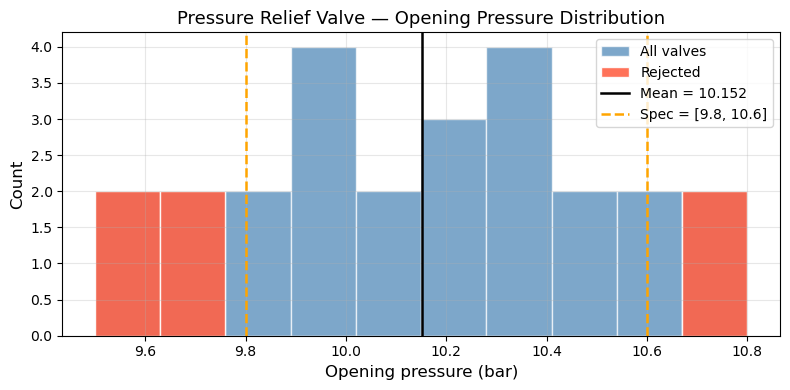

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

P = np.array([10.2, 9.8, 10.5, 10.1, 9.6,
              10.4, 9.9, 10.3, 10.7, 9.7,
              10.0, 10.6, 9.5, 10.2, 10.4,
              10.8, 9.9, 10.1, 10.3, 9.8,
              10.5, 10.0, 9.7, 10.6, 10.2])

lo_spec, hi_spec = 9.8, 10.6

# ── (a) Descriptive statistics ────────────────────────────────────────────────
mean_P = np.mean(P)
std_P  = np.std(P, ddof=1)
q1, q3 = np.percentile(P, 25), np.percentile(P, 75)

print("(a) Descriptive Statistics")
print(f"  Mean   : {mean_P:.4f} bar")
print(f"  Median : {np.median(P):.4f} bar")
print(f"  Std    : {std_P:.4f} bar  (sample, ddof=1)")
print(f"  Min    : {np.min(P):.2f} bar")
print(f"  Max    : {np.max(P):.2f} bar")
print(f"  IQR    : {q3 - q1:.4f} bar  (Q1={q1:.2f}, Q3={q3:.2f})")

# ── (b) Rejection analysis ────────────────────────────────────────────────────
rejected = P[(P < lo_spec) | (P > hi_spec)]
print(f"\n(b) Rejection Analysis")
print(f"  Rejected valves : {len(rejected)} / {len(P)}  ({100*len(rejected)/len(P):.1f}%)")
print(f"  Rejected values : {rejected}")

# ── (c) Theoretical rejection probability ─────────────────────────────────────
dist_P = stats.norm(loc=mean_P, scale=std_P)
p_reject_theory = 1 - (dist_P.cdf(hi_spec) - dist_P.cdf(lo_spec))
# explanation: P(outside spec) = 1 - P(within spec) = 1 - [P(P ≤ hi_spec) - P(P < lo_spec)]
print(f"\n(c) Theoretical vs Observed Rejection Rate")
print(f"  Theoretical P(outside spec) = {p_reject_theory:.4f}  ({100*p_reject_theory:.2f}%)")
print(f"  Observed rejection rate      = {len(rejected)/len(P):.4f}  ({100*len(rejected)/len(P):.2f}%)")

# ── (d) Histogram plot ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

# Histogram of all valves
ax.hist(P, bins=10, color='steelblue', edgecolor='white', alpha=0.7, label='All valves')

# Overlay rejected valves in red
ax.hist(rejected, bins=10, color='tomato', edgecolor='white', alpha=0.9, label='Rejected')

ax.axvline(mean_P,   color='black',  linestyle='-',  linewidth=1.8, label=f'Mean = {mean_P:.3f}')
ax.axvline(lo_spec,  color='orange', linestyle='--', linewidth=1.8, label=f'Spec = [{lo_spec}, {hi_spec}]')
ax.axvline(hi_spec,  color='orange', linestyle='--', linewidth=1.8)

ax.set_xlabel('Opening pressure (bar)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Pressure Relief Valve — Opening Pressure Distribution', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Problem 2: Random Sampling and Distribution Analysis

A flow meter has a known measurement error that follows a **Uniform distribution** over $[-0.5,\; +0.5]$ L/min. The true flow rate is 100 L/min, so measured values = $100 + \text{Uniform}(-0.5, 0.5)$.

**(a)** Using `np.random.default_rng(seed=21)`, generate 500 simulated measurements. Compute the sample mean and sample std. Compare them to the theoretical mean and std of the Uniform distribution.

**(b)** What fraction of measurements fall outside $[99.7,\; 100.3]$ L/min? Compute it both from the simulated samples and theoretically using `scipy.stats.uniform`.

**(c)** Now suppose the flow meter is **replaced** with a better instrument whose error follows a **Normal distribution** $\mathcal{N}(0,\; 0.2^2)$. Using the same seed and 500 samples, what fraction of measurements now fall outside $[99.7,\; 100.3]$ L/min? Again compute both from simulation and from the Normal CDF.

**(d)** Plot side-by-side histograms of the simulated measurements for both instruments on the same x-axis range. Add vertical lines at 99.7 and 100.3. Which instrument is more likely to give a reading within spec?

(a) Uniform instrument — sample vs theoretical
  Sample mean : 99.9954 L/min  (theoretical: 100.0)
  Sample std  : 0.2876 L/min  (theoretical: 0.2887)

(b) Fraction outside [99.7, 100.3] — Uniform instrument
  Simulated  : 0.3760  (37.6%)
  Theoretical: 0.4000  (40.0%)

(c) Fraction outside [99.7, 100.3] — Normal instrument (σ=0.2)
  Simulated  : 0.1080  (10.8%)
  Theoretical: 0.1336  (13.4%)

→ Normal instrument has lower out-of-spec rate: 13.4% vs 40.0% (Uniform)


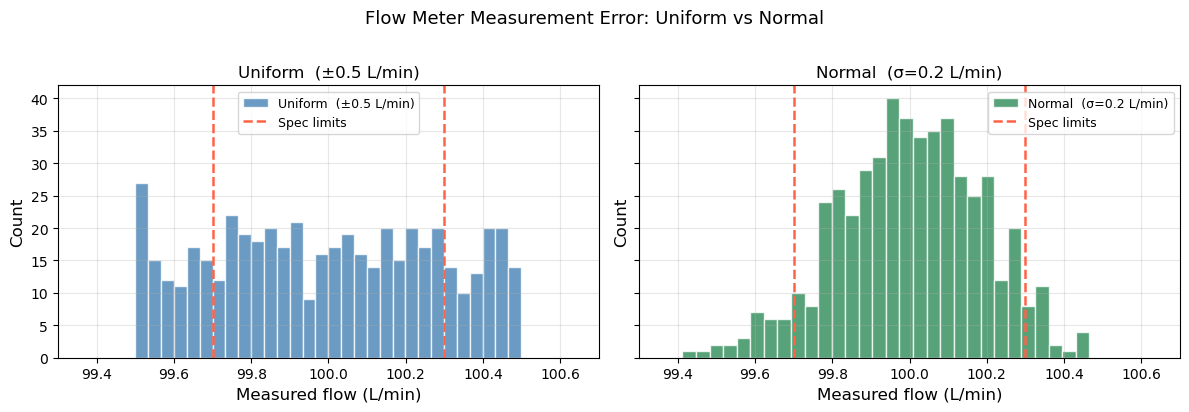

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

true_flow = 100.0
lo_spec, hi_spec = 99.7, 100.3

# ── (a) Uniform instrument: 500 samples ──────────────────────────────────────
rng = np.random.default_rng(seed=21)
errors_unif = rng.uniform(-0.5, 0.5, 500)
meas_unif   = true_flow + errors_unif

print("(a) Uniform instrument — sample vs theoretical")
print(f"  Sample mean : {np.mean(meas_unif):.4f} L/min  (theoretical: {true_flow:.1f})")
print(f"  Sample std  : {np.std(meas_unif, ddof=1):.4f} L/min  (theoretical: {1/np.sqrt(12):.4f})")
# explanation: Uniform(a, b) has mean = (a+b)/2 and std = (b-a)/sqrt(12)

# ── (b) Fraction outside spec — Uniform ──────────────────────────────────────
frac_out_unif_sim = np.mean((meas_unif < lo_spec) | (meas_unif > hi_spec))
# explanation: count how many measurements are outside the spec limits, then divide by total samples

# Theoretical: Uniform(99.5, 100.5), spec is [99.7, 100.3]
dist_unif = stats.uniform(loc=true_flow - 0.5, scale=1.0)
p_in_spec_unif  = dist_unif.cdf(hi_spec) - dist_unif.cdf(lo_spec)
p_out_unif_theory = 1 - p_in_spec_unif

print(f"\n(b) Fraction outside [{lo_spec}, {hi_spec}] — Uniform instrument")
print(f"  Simulated  : {frac_out_unif_sim:.4f}  ({100*frac_out_unif_sim:.1f}%)")
print(f"  Theoretical: {p_out_unif_theory:.4f}  ({100*p_out_unif_theory:.1f}%)")

# ── (c) Normal instrument: same seed, 500 samples ────────────────────────────
rng = np.random.default_rng(seed=21)
errors_norm = rng.normal(0, 0.2, 500)
meas_norm   = true_flow + errors_norm

frac_out_norm_sim = np.mean((meas_norm < lo_spec) | (meas_norm > hi_spec))

dist_norm = stats.norm(loc=true_flow, scale=0.2)
p_out_norm_theory = 1 - (dist_norm.cdf(hi_spec) - dist_norm.cdf(lo_spec))

print(f"\n(c) Fraction outside [{lo_spec}, {hi_spec}] — Normal instrument (σ=0.2)")
print(f"  Simulated  : {frac_out_norm_sim:.4f}  ({100*frac_out_norm_sim:.1f}%)")
print(f"  Theoretical: {p_out_norm_theory:.4f}  ({100*p_out_norm_theory:.1f}%)")

print(f"\n→ Normal instrument has lower out-of-spec rate: "
      f"{100*p_out_norm_theory:.1f}% vs {100*p_out_unif_theory:.1f}% (Uniform)")

# ── (d) Side-by-side histograms ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
x_range = (99.3, 100.7)

for ax, meas, label, color in [
        (axes[0], meas_unif, 'Uniform  (±0.5 L/min)',  'steelblue'),
        (axes[1], meas_norm, 'Normal  (σ=0.2 L/min)',  'seagreen'),
]:
    ax.hist(meas, bins=30, color=color, edgecolor='white', alpha=0.8, label=label)
    ax.axvline(lo_spec, color='tomato', linestyle='--', linewidth=1.8, label='Spec limits')
    ax.axvline(hi_spec, color='tomato', linestyle='--', linewidth=1.8)
    ax.set_xlim(x_range)
    ax.set_xlabel('Measured flow (L/min)', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(label, fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Flow Meter Measurement Error: Uniform vs Normal', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()